# Sandbox - Hyper-Parameters optimisation

This notebook is used to prototype the Hyper-Parameters optimisation process, in all scenarios of use of the algorithm.

---

## Imports & Config

In [1]:
from pygments.formatters import load_formatter_from_file
! pwd

/Users/simonlejoly/Documents/Work/mimosa/tests


In [2]:
! export XLA_PYTHON_CLIENT_MEM_FRACTION=.25

In [3]:
# Jax configuration
USE_JIT = True
USE_X64 = True
DEBUG_NANS = False
VERBOSE = False

In [4]:
# Standard library imports
import os
os.environ['JAX_ENABLE_X64'] = str(USE_X64).lower()

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

from typing import Tuple
from tqdm import tqdm

In [5]:
# Third party
import jax
jax.config.update("jax_disable_jit", not USE_JIT)
jax.config.update("jax_debug_nans", DEBUG_NANS)
import jax.random as jr
import jax.numpy as jnp
import jax.scipy as jsp
from jax import vmap, jit, Array, grad

from equinox import filter_jit
import numpy as np

import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from kernax import WhiteNoiseKernel, VarianceKernel, SEKernel, AffineMean, AbstractMean, AbstractKernel

In [6]:
# Local imports
from mimosa.linalg import cho_factor, cho_solve
from mimosa.generate_data import generate_data
from mimosa.hyperpost import hyperpost
from mimosa.sampling import sample_gp
from mimosa.nll import means_nlls, tasks_nlls, full_nll

INFO:2026-04-10 15:19:30,049:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/miniconda3/envs/mimosa/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
2026-04-10 15:19:30,049 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/miniconda3/envs/mimosa/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


In [7]:
# Config
key = jr.PRNGKey(45)

T=333 ; K=3 ; F=1 ; N=150 ; I=1 ; O=1 ; gs=250 if I == 1 else 40

sth=True ; sch=True ; chit=False ; fh=False ; soh=True ; siit=False ; siif=True

mean = AffineMean(slope=0., intercept=0.)
mean_kernel = VarianceKernel(20.) * SEKernel(length_scale=10.)
task_kernel = VarianceKernel(.2) * SEKernel(length_scale=9.) + WhiteNoiseKernel(noise=.01)

mean_priors = {
	"slope": (-.2, .2),
	"intercept": (-2.5, 2.5)
}

mean_kernel_priors = {
	"variance": (5, 10.),
	"length_scale": (2.5, 10.)
}

task_kernel_priors = {
	"variance": (0.25, 1.),
	"length_scale": (2., 8.),
	"noise": (0.01, 0.1)
}

jax.devices()

[CpuDevice(id=0)]

In [8]:
inputs, outputs, maps, grid, m_p_means, m_p_covs, m_p, mix, t_m, m, m_k, t_k = generate_data(
	key, T, K, F, N,  I, O, gs,
	mean, mean_kernel, task_kernel,
	mean_priors, mean_kernel_priors, task_kernel_priors,
	sth, sch, chit, fh, soh, siit, siif)

In [9]:
mix_coeffs = jnp.eye(K)[mix]
mix_coeffs.shape

(333, 3)

In [10]:
p_m, p_c = hyperpost(inputs, outputs, maps, grid, mix_coeffs, m, m_k, t_k)
p_m.shape, p_c.shape

((3, 1, 250), (3, 1, 250, 250))

In [11]:
print(t_k)

VarianceKernel(variance=0.78) * SEKernel(length_scale=2.89) + WhiteNoiseKernel(noise=0.02)


---

## HP Optimisation

Based on:
- An optimiser (LBFG-S, Adam, ...)
- Training config (shared HPs across clusters, tasks, features, outputs, ...)
- Mean processes (post_means, post_covs)
- Mixtures proportions and coefficients
- Trainable parameters (cluster_mean, cluster_kernel, task_kernel, ...)
- Freezing maps for every trainable parameters

We want to provide updated parameters, optimising the cluster and task likelihoods, as fast as possible

In [12]:
import optimistix as optx
import equinox as eqx

In [13]:
train_clust_mean = m.replace(slope=mean.slope, intercept=mean.intercept)
train_clust_kern = m_k.replace(length_scale=mean_kernel.right.length_scale, variance=mean_kernel.left.variance)
train_task_kern = t_k.replace(length_scale=task_kernel.left.right.length_scale/2, variance=task_kernel.left.left.variance, noise=task_kernel.right.noise)
print(f"{train_clust_mean}\n{train_clust_kern}\n{train_task_kern}")

AffineMean(slope=0.00, intercept=0.00)
VarianceKernel(variance=20.00) * SEKernel(length_scale=10.00)
VarianceKernel(variance=0.20) * SEKernel(length_scale=4.50) + WhiteNoiseKernel(noise=0.01)


In [14]:
true_clust_mean = m
true_clust_kern = m_k
true_task_kern = t_k

print(f"{true_clust_mean}\n{true_clust_kern}\n{true_task_kern}")

AffineMean(slope=0.10, intercept=2.42)
VarianceKernel(variance=8.79) * SEKernel(length_scale=7.35)
VarianceKernel(variance=0.78) * SEKernel(length_scale=2.89) + WhiteNoiseKernel(noise=0.02)


### Cluster optimisation

In [15]:
solver = optx.LBFGS(atol=1e-5, rtol=1e-5)
y0 = (train_clust_mean, train_clust_kern)
loss_fn = lambda y, _: means_nlls(p_m, p_c, grid, y[0](grid), y[1](grid)).sum()

In [16]:
opti_clust_mean, opti_clust_kern = optx.minimise(loss_fn, solver, y0).value
print(f"{opti_clust_mean}\n{opti_clust_kern}")

AffineMean(slope=0.10, intercept=1.08)
VarianceKernel(variance=7.90) * SEKernel(length_scale=7.27)


In [17]:
init_likelihood = means_nlls(p_m, p_c, grid, train_clust_mean(grid), train_clust_kern(grid))
true_likelihood = means_nlls(p_m, p_c, grid, true_clust_mean(grid), true_clust_kern(grid))
opti_likelihood = means_nlls(p_m, p_c, grid, opti_clust_mean(grid), opti_clust_kern(grid))

print(f"Initial likelihood: {loss_fn((train_clust_mean, train_clust_kern), None).item()}, true likelihood: {loss_fn((true_clust_mean, true_clust_kern), None).item()}, opti likelihood: {loss_fn((opti_clust_mean, opti_clust_kern), None).item()}")

Initial likelihood: -108.3860311904374, true likelihood: -2424.4066623185477, opti likelihood: -2426.7860312398598


### Task optimisation

In [18]:
task_llhs = tasks_nlls(inputs, outputs, maps, t_k(inputs), p_m, p_c, jitter=jnp.array(1e-3))  # FIXME: here we use the "true" mean and kernel, but in the real pipeline we have to use the first estimate
mix_prop = (jnp.ones((K,)) / K)[:, None]
new_mix_coeffs = jax.nn.softmax(jnp.log(mix_prop) - task_llhs, axis=1)
new_mix = jnp.argmax(new_mix_coeffs, axis=1).squeeze()

In [19]:
task_llhs.shape

(333, 3, 1)

In [20]:
task_llhs * jnp.eye(K)[mix][..., None]

Array([[[-4.78258103e+00],
        [ 0.00000000e+00],
        [ 0.00000000e+00]],

       [[ 9.18923894e+00],
        [ 0.00000000e+00],
        [ 0.00000000e+00]],

       [[-1.32729398e+01],
        [ 0.00000000e+00],
        [ 0.00000000e+00]],

       [[ 1.36647368e+00],
        [ 0.00000000e+00],
        [ 0.00000000e+00]],

       [[ 4.00828188e+01],
        [ 0.00000000e+00],
        [ 0.00000000e+00]],

       [[-5.14971844e+00],
        [ 0.00000000e+00],
        [ 0.00000000e+00]],

       [[ 1.40572169e+01],
        [ 0.00000000e+00],
        [ 0.00000000e+00]],

       [[ 2.18943285e+00],
        [ 0.00000000e+00],
        [ 0.00000000e+00]],

       [[-4.19972064e+00],
        [ 0.00000000e+00],
        [ 0.00000000e+00]],

       [[ 1.85725179e+00],
        [ 0.00000000e+00],
        [ 0.00000000e+00]],

       [[-4.72673520e+00],
        [ 0.00000000e+00],
        [ 0.00000000e+00]],

       [[ 4.47463910e+00],
        [ 0.00000000e+00],
        [ 0.00000000e+00]],

    

In [21]:
jnp.eye(K)[mix][..., None].shape

(333, 3, 1)

In [22]:
y0 = train_task_kern
loss_fn = lambda y, _: (tasks_nlls(inputs, outputs, maps, y(inputs), p_m, p_c, jitter=jnp.array(1e-8)) * jnp.eye(K)[mix][..., None]).sum()

In [23]:
opti_task_kern = optx.minimise(loss_fn, solver, y0).value
print(f"{opti_task_kern}")

E0410 15:19:34.138214 7271726 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %gather.20 = f64[49950,3,1,1,250]{4,3,2,1,0} gather(%constant.934, %constant.1054), offset_dims={1,2,3,4}, collapsed_slice_dims={}, start_index_map={2}, index_vector_dim=1, slice_sizes={3,1,1,250}, metadata={op_name="jit(minimise)/while/body/jvp(jit(tasks_nlls))/vmap(vmap())/gather" stack_frame_id=13}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0410 15:19:34.390390 7271574 slow_operation_alarm.cc:140] The operation took 1.257197s
Constant folding an instruction is taking > 1s:

  %gather.20 = f64[49950,3,1,1,250]{4,3,2,1,0} gat

VarianceKernel(variance=0.79) * SEKernel(length_scale=2.89) + WhiteNoiseKernel(noise=0.02)


In [24]:
init_likelihood = tasks_nlls(inputs, outputs, maps, train_task_kern(inputs), p_m, p_c, jitter=jnp.array(1e-1))
true_likelihood = tasks_nlls(inputs, outputs, maps, true_task_kern(inputs), p_m, p_c, jitter=jnp.array(1e-1))
opti_likelihood = tasks_nlls(inputs, outputs, maps, opti_task_kern(inputs), p_m, p_c, jitter=jnp.array(1e-1))

print(f"Initial likelihood: {loss_fn(train_task_kern, None).item()}, true likelihood: {loss_fn(true_task_kern, None).item()}, opti likelihood: {loss_fn(opti_task_kern, None).item()}")

Initial likelihood: 73836.81877861575, true likelihood: 83.43635992938373, opti likelihood: 83.23684966834719


In [40]:
test_kernel = t_k.inner.inner.inner
test_kernel_2 = opti_task_kern.inner.inner.inner

print(f"true kernel: \t{test_kernel}\noptimal kernel:\t{test_kernel_2}")

true kernel: 	VarianceKernel(variance=0.78) * SEKernel(length_scale=2.89) + WhiteNoiseKernel(noise=0.02)
optimal kernel:	VarianceKernel(variance=0.79) * SEKernel(length_scale=2.89) + WhiteNoiseKernel(noise=0.02)


In [26]:
p_m.shape, p_c.shape

((3, 1, 250), (3, 1, 250, 250))

In [27]:
inputs[0].shape, outputs[0].shape, p_m[0][:, maps[0]].shape, test_kernel(inputs[0]).shape, p_c[0, 0][maps[0], :][:, maps[0]].shape

((150, 1), (150, 1), (1, 150), (150, 150), (150, 150))

In [28]:
inputs[1].shape, outputs[1].shape, p_m[0][:, maps[1]].shape, test_kernel(inputs[1]).shape, p_c[0, 0][maps[1], :][:, maps[1]].shape

((150, 1), (150, 1), (1, 150), (150, 150), (150, 150))

In [29]:
full_nll(inputs[0], outputs[0], p_m[0][:, maps[0]], test_kernel(inputs[0]), p_c[0, 0][maps[0], :][:, maps[0]], jnp.array(1e-3))

Array([-4.78258103], dtype=float64)

In [30]:
full_nll(inputs[0], outputs[0], p_m[0][:, maps[0]], test_kernel_2(inputs[0]), p_c[0, 0][maps[0], :][:, maps[0]], jnp.array(1e-3))

Array([-4.80675834], dtype=float64)

In [31]:
full_nll(inputs[1], outputs[1], p_m[0][:, maps[1]], test_kernel(inputs[1]), p_c[0, 0][maps[1], :][:, maps[1]], jnp.array(1e-3))

Array([9.18923894], dtype=float64)

In [32]:
full_nll(inputs[1], outputs[1], p_m[0][:, maps[1]], test_kernel_2(inputs[1]), p_c[0, 0][maps[1], :][:, maps[1]], jnp.array(1e-3))

Array([9.11532455], dtype=float64)

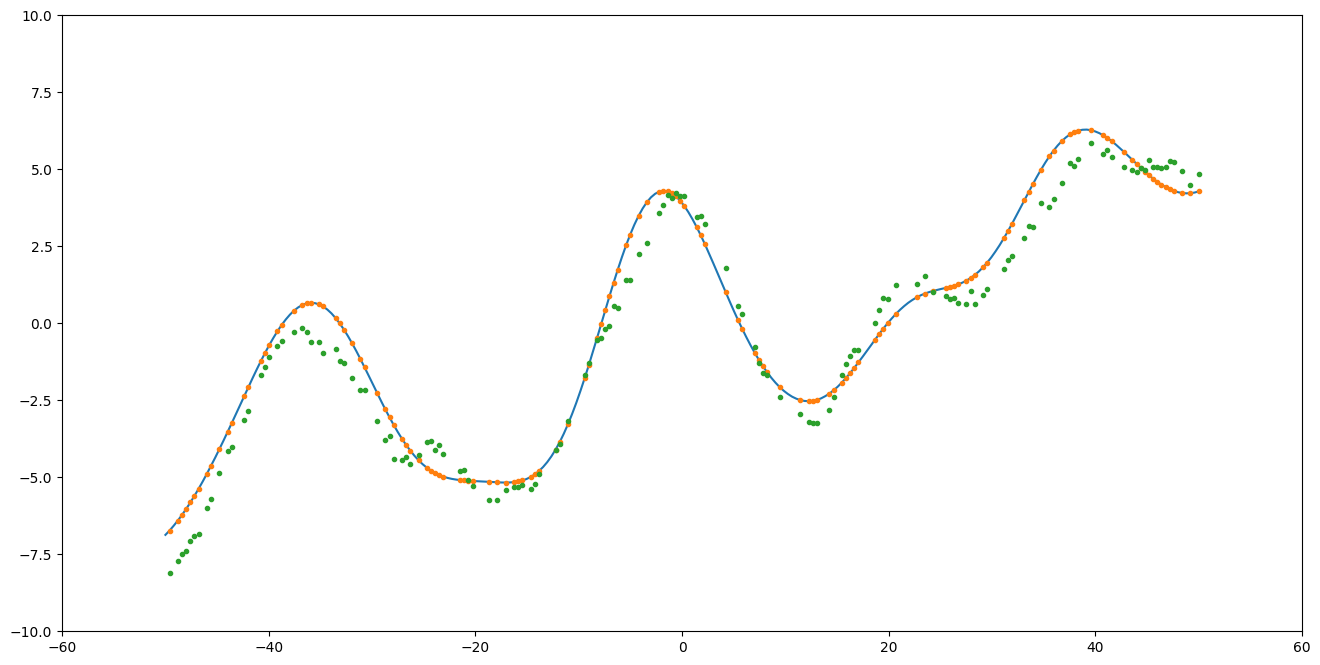

In [33]:
i = 10
fig = plt.figure(figsize=(16, 8))
plt.plot(grid.squeeze(), p_m[0].squeeze())
plt.plot(inputs[i].squeeze(), p_m[0][:, maps[i]].squeeze(), marker='.', linestyle='none')
plt.plot(inputs[i].squeeze(), outputs[i].squeeze(), marker='.', linestyle='none')
plt.ylim(-10, 10)
plt.xlim(-60, 60)
plt.show()

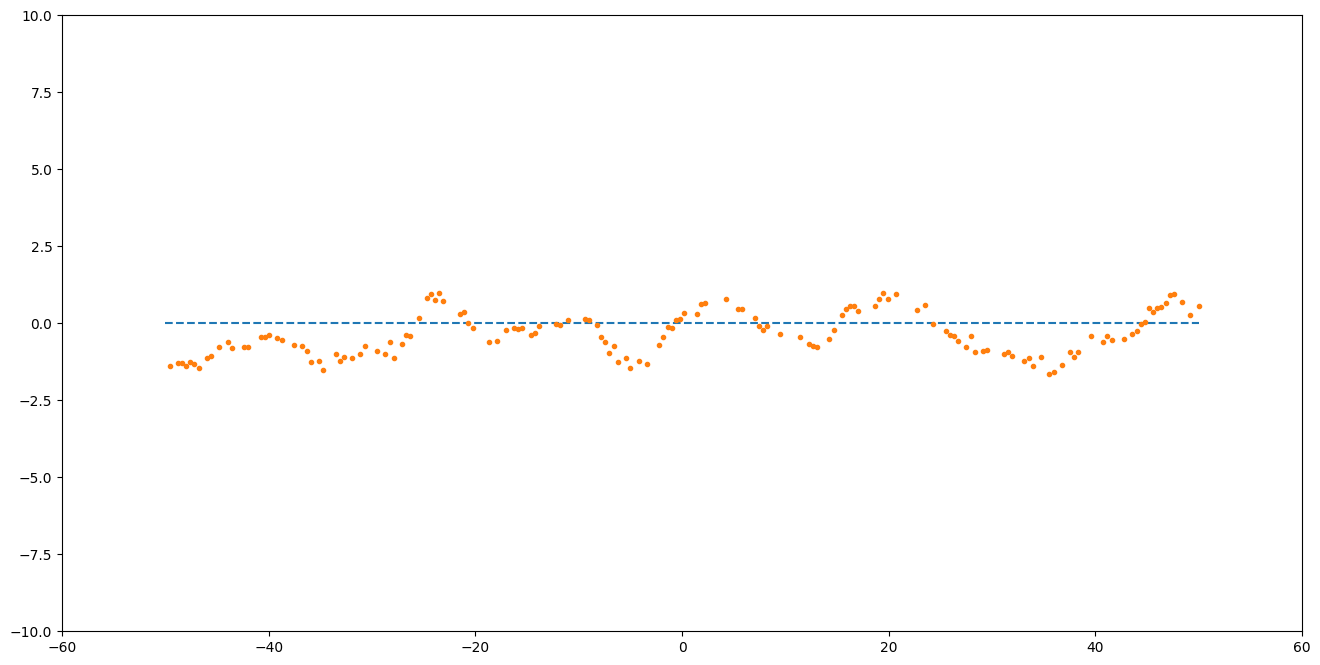

In [34]:
i = 10
fig = plt.figure(figsize=(16, 8))
plt.plot(grid.squeeze(), jnp.zeros_like(grid.squeeze()), linestyle='--')
plt.plot(inputs[i].squeeze(), outputs[i].squeeze() - p_m[0][:, maps[i]].squeeze(), marker='.', linestyle='none')
plt.ylim(-10, 10)
plt.xlim(-60, 60)
plt.show()

In [35]:
inputs[1]

Array([[-13.85542169],
       [-30.72289157],
       [ 39.95983936],
       [-36.74698795],
       [-19.87951807],
       [-23.4939759 ],
       [-13.45381526],
       [ 47.59036145],
       [  8.23293173],
       [-11.04417671],
       [ 45.18072289],
       [ 42.36947791],
       [ 38.75502008],
       [-41.96787149],
       [-21.8875502 ],
       [ 26.30522088],
       [ 33.13253012],
       [-12.24899598],
       [ 34.3373494 ],
       [ 44.77911647],
       [ 44.37751004],
       [-46.38554217],
       [ 22.28915663],
       [ 46.38554217],
       [ -5.02008032],
       [  1.40562249],
       [ -3.81526104],
       [ -9.03614458],
       [ 42.77108434],
       [-42.77108434],
       [ -9.83935743],
       [-23.09236948],
       [ 40.36144578],
       [ 48.79518072],
       [ 38.35341365],
       [ 11.84738956],
       [ 24.69879518],
       [-39.15662651],
       [ 37.95180723],
       [-50.        ],
       [ 19.47791165],
       [-35.14056225],
       [ -3.01204819],
       [  8

In [36]:
true_llhs = []
opti_llhs = []

for i in range(T):

	true_llhs.append(full_nll(inputs[i], outputs[i], p_m[mix[i]][:, maps[i]], test_kernel(inputs[i]), p_c[mix[i], 0][maps[i], :][:, maps[i]], jnp.array(1e-3)))
	opti_llhs.append(full_nll(inputs[i], outputs[i], p_m[mix[i]][:, maps[i]], test_kernel_2(inputs[i]), p_c[mix[i], 0][maps[i], :][:, maps[i]], jnp.array(1e-3)))

true_llhs, opti_llhs

([Array([-4.78258103], dtype=float64),
  Array([9.18923894], dtype=float64),
  Array([-13.27293979], dtype=float64),
  Array([1.36647368], dtype=float64),
  Array([40.08281881], dtype=float64),
  Array([-5.14971844], dtype=float64),
  Array([14.05721693], dtype=float64),
  Array([2.18943285], dtype=float64),
  Array([-4.19972064], dtype=float64),
  Array([1.85725179], dtype=float64),
  Array([-4.7267352], dtype=float64),
  Array([4.4746391], dtype=float64),
  Array([-5.55814862], dtype=float64),
  Array([7.81591155], dtype=float64),
  Array([-8.5383539], dtype=float64),
  Array([1.17060858], dtype=float64),
  Array([-4.4384645], dtype=float64),
  Array([4.68499179], dtype=float64),
  Array([11.55230678], dtype=float64),
  Array([-8.32061235], dtype=float64),
  Array([11.70546085], dtype=float64),
  Array([-4.466739], dtype=float64),
  Array([-2.8518944], dtype=float64),
  Array([1.48256385], dtype=float64),
  Array([3.5852894], dtype=float64),
  Array([-3.04923941], dtype=float64),
  A

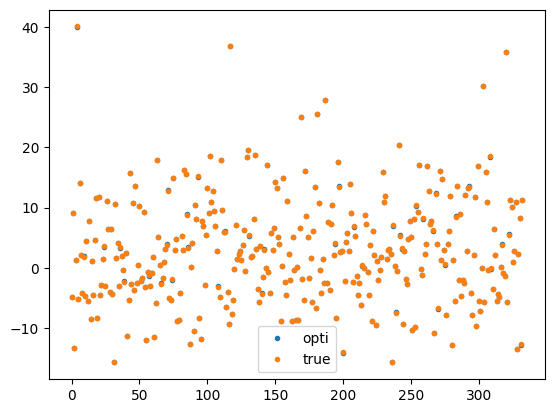

In [37]:
plt.plot(opti_llhs, marker=".", label="opti", linestyle="none")
plt.plot(true_llhs, marker=".", label="true", linestyle="none")
plt.legend()
plt.show()

In [38]:
0/0

ZeroDivisionError: division by zero

In [13]:
def optimise_clusters(
		cluster_mean: AbstractMean, cluster_kern: AbstractKernel,
		grid: Array, post_means: Array, post_covs: Array,
		cluster_mean_frozen_map: AbstractMean, cluster_kernel_frozen_map: AbstractKernel,
		optimiser: eqx.Module = optx.LBFGS(rtol=1e-3, atol=1e-3), jitter: Array = jnp.array(1e-5)) -> Tuple[AbstractMean, AbstractKernel]:

	def loss_fn(trainables, frozen, ):
		pass



SyntaxError: expected ':' (4288499241.py, line 2)